# EDA Lab for the InfoEdge Data Scientist Interviews
**Companion notebook to Part VIII of the InfoEdge Interview Companion PDF.**

Four complete, interview-style exploratory data analyses, each written the way you would narrate it in Round 3:

| # | Dataset | Rows | Why it is here |
|---|---|---|---|
| 1 | MBA campus placement (the dataset reported in InfoEdge Round 3) | 215 | target leakage through *salary*, score–placement patterns, small-data judgement |
| 2 | HR Analytics: job change of data scientists (real, from this repo) | 19,158 | messy categoricals, informative missingness, high-cardinality city, imbalance — very close to Naukri data |
| 3 | Titanic (real, from this repo) | 891 | interactions (sex × class), feature extraction from text (titles), group-wise imputation |
| 4 | Pima Indians diabetes (real, from this repo) | 768 | *disguised* missing values coded as 0 |

**How to use in Google Colab:** File → Upload notebook (or open from GitHub), then *Runtime → Run all*. The real datasets are read
directly from the GitHub repo. For the MBA dataset, download `Placement_Data_Full_Class.csv` from Kaggle
(“Campus Recruitment” / “Factors affecting campus placement”) and upload it to the Colab session; if it is absent, the notebook builds a
**simulated replica with the same columns** so every cell still runs. Numbers in the PDF for case 1 come from that replica.

**The habit to build:** after every output, say one sentence: *“Because I see X, I will do Y.”*

In [1]:
import os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
warnings.filterwarnings("ignore")
pd.set_option("display.width", 120); pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 3)
sns.set_theme(style="whitegrid", palette="deep", font_scale=0.9)
plt.rcParams["figure.dpi"] = 110

REPO_RAW = "https://raw.githubusercontent.com/nthapa000/Machine_Learning_from_scratch/master/"
FIG_DIR = "figs"                       # figures are saved only when this folder exists (PDF build)

def load_csv(rel_path, **kw):
    # Local repo copy first (when run inside the repo), else read the public GitHub copy (Colab).
    for p in [rel_path, os.path.join("..", "..", rel_path), os.path.basename(rel_path)]:
        if os.path.exists(p):
            return pd.read_csv(p, **kw)
    return pd.read_csv(REPO_RAW + rel_path, **kw)

def save(name):
    if os.path.isdir(FIG_DIR):
        plt.savefig(f"{FIG_DIR}/{name}.png", dpi=130, bbox_inches="tight")
    plt.show()
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.6 | numpy 2.4.6


## 0. A reusable EDA toolkit
Write these once, use them on every dataset. Each function answers one interview question.

In [2]:
def overview(df):
    # One row per column: type, missing %, number of unique values, an example value.
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_%": (df.isna().mean() * 100).round(1),
        "n_unique": df.nunique(),
        "example": df.apply(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan),
    })

def num_summary(df):
    # describe() plus shape statistics and outlier counts for every numeric column.
    num = df.select_dtypes("number")
    q1, q3 = num.quantile(0.25), num.quantile(0.75)
    iqr = q3 - q1
    out = ((num < q1 - 1.5 * iqr) | (num > q3 + 1.5 * iqr)).sum()
    res = num.describe().T
    res["skew"] = num.skew(); res["kurt"] = num.kurt()
    res["n_iqr_outliers"] = out; res["n_zeros"] = (num == 0).sum()
    return res.round(2)

def rate_by(df, col, target, bins=None, q=None):
    # Target rate and count per category (or per bin of a numeric column).
    key = df[col]
    if bins is not None: key = pd.cut(key, bins)
    elif q is not None:  key = pd.qcut(key, q, duplicates="drop")
    key = key.astype(object).where(key.notna(), "MISSING")
    g = df.groupby(key, observed=True)[target].agg(rate="mean", n="size")
    return g.round(3)

def missing_vs_target(df, target):
    # Does being missing change the target rate? (informative missingness / leakage check)
    rows = []
    for c in df.columns.drop(target):
        m = df[c].isna()
        if 0 < m.sum() < len(df):
            rows.append((c, round(m.mean() * 100, 1), df.loc[m, target].mean(), df.loc[~m, target].mean()))
    return pd.DataFrame(rows, columns=["column", "missing_%", "target_rate_if_missing",
                                       "target_rate_if_present"]).round(3)

def point_biserial(df, num_cols, target):
    # Correlation of each numeric feature with a 0/1 target (Chapter 32), with p-values.
    rows = []
    for c in num_cols:
        d = df[[c, target]].dropna()
        r, p = stats.pointbiserialr(d[target], d[c])
        rows.append((c, r, p))
    return pd.DataFrame(rows, columns=["feature", "r_pb", "p_value"]).sort_values("r_pb", key=abs, ascending=False).round(4)

def cramers_v(x, y):
    # Strength of association between two categorical variables (0..1).
    t = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(t, correction=False)[0]
    k = min(t.shape) - 1
    return np.sqrt(chi2 / (t.values.sum() * k))

def vif(df_num):
    # Variance inflation factor: regress each column on the others, VIF = 1/(1-R^2).
    X = df_num.dropna().values; out = {}
    for j, c in enumerate(df_num.columns):
        y = X[:, j]; A = np.column_stack([np.ones(len(X)), np.delete(X, j, axis=1)])
        coef, *_ = np.linalg.lstsq(A, y, rcond=None)
        r2 = 1 - ((y - A @ coef) ** 2).sum() / ((y - y.mean()) ** 2).sum()
        out[c] = 1 / (1 - r2)
    return pd.Series(out, name="VIF").round(2)
print("toolkit ready")

toolkit ready


---
# Case 1 — MBA campus placement
**Business question:** which students get placed, and what drives it? **Target:** `status` (Placed / Not Placed).
Columns: `ssc_p` (10th %), `ssc_b` (10th board), `hsc_p` (12th %), `hsc_b`, `hsc_s` (12th stream), `degree_p`, `degree_t` (degree type),
`workex`, `etest_p` (employability test %), `specialisation` (MBA), `mba_p`, `status`, `salary` (offer, only if placed).

In [3]:
def make_placement_replica(n=215, seed=42):
    rng = np.random.default_rng(seed)
    gender = rng.choice(["M", "F"], n, p=[0.65, 0.35])
    ssc_p = np.clip(rng.normal(67, 10.8, n), 40, 89.4).round(2)
    ssc_b = rng.choice(["Central", "Others"], n, p=[0.54, 0.46])
    hsc_p = np.clip(0.55 * ssc_p + rng.normal(29.5, 8.5, n), 37, 97.7).round(2)
    hsc_b = rng.choice(["Central", "Others"], n, p=[0.39, 0.61])
    hsc_s = rng.choice(["Commerce", "Science", "Arts"], n, p=[0.53, 0.42, 0.05])
    degree_p = np.clip(0.35 * ssc_p + rng.normal(43, 5.8, n), 50, 91).round(2)
    degree_t = np.where(hsc_s == "Science", rng.choice(["Sci&Tech", "Comm&Mgmt", "Others"], n, p=[0.6, 0.3, 0.1]),
                        rng.choice(["Comm&Mgmt", "Sci&Tech", "Others"], n, p=[0.9, 0.05, 0.05]))
    workex = rng.choice(["No", "Yes"], n, p=[0.655, 0.345])
    etest_p = np.clip(rng.normal(72, 13, n), 50, 98).round(2)
    specialisation = rng.choice(["Mkt&Fin", "Mkt&HR"], n, p=[0.56, 0.44])
    mba_p = np.clip(0.1 * degree_p + rng.normal(55.5, 5.5, n), 51.2, 77.9).round(2)
    z = (-27.1 + 0.20 * ssc_p + 0.09 * hsc_p + 0.10 * degree_p + 3.0 * (workex == "Yes")
         + 2.4 * (specialisation == "Mkt&Fin") + 0.01 * etest_p - 0.06 * (mba_p - 62)
         + rng.normal(0, 0.9, n))
    placed = rng.random(n) < 1 / (1 + np.exp(-z))
    base = (200000 + 4200 * (ssc_p - 60) + 2500 * (degree_p - 65) + 45000 * (workex == "Yes")
            + 25000 * (gender == "M") + 20000 * (specialisation == "Mkt&Fin"))
    salary = base * np.exp(rng.normal(0, 0.18, n))
    salary = np.clip(salary, 200000, None)
    top = rng.random(n) < 0.03                      # a few genuinely high packages
    salary = np.where(top, salary * rng.uniform(1.8, 3.2, n), salary)
    salary = np.where(placed, (salary / 1000).round() * 1000, np.nan)
    return pd.DataFrame(dict(sl_no=np.arange(1, n + 1), gender=gender, ssc_p=ssc_p, ssc_b=ssc_b,
        hsc_p=hsc_p, hsc_b=hsc_b, hsc_s=hsc_s, degree_p=degree_p, degree_t=degree_t, workex=workex,
        etest_p=etest_p, specialisation=specialisation, mba_p=mba_p,
        status=np.where(placed, "Placed", "Not Placed"), salary=salary))

if os.path.exists("Placement_Data_Full_Class.csv"):
    pl = pd.read_csv("Placement_Data_Full_Class.csv"); SOURCE = "REAL Kaggle file"
else:
    pl = make_placement_replica(); SOURCE = "SIMULATED replica (same schema)"
print("Data source:", SOURCE)
print(pl.shape)
pl.head()

Data source: SIMULATED replica (same schema)
(215, 15)


,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,F,52.67,Others,56.04,Others,Science,57.82,Sci&Tech,No,98.00,Mkt&HR,72.40,Not Placed,NaN
1,2,M,67.33,Others,64.92,Others,Science,66.70,Sci&Tech,No,65.19,Mkt&Fin,52.63,Placed,263000.0
2,3,F,61.77,Others,54.01,Central,Commerce,61.14,Comm&Mgmt,No,77.49,Mkt&Fin,64.36,Not Placed,NaN
3,4,F,63.46,Central,69.33,Central,Commerce,74.61,Comm&Mgmt,No,85.89,Mkt&HR,53.73,Not Placed,NaN
4,5,M,77.83,Others,76.76,Others,Commerce,72.35,Comm&Mgmt,No,73.27,Mkt&HR,62.14,Placed,274000.0


### 1.1 First look: structure, types, missing values
*Why:* before any statistic we confirm what one row is, which columns are numbers vs categories, and where data are missing.

In [4]:
overview(pl)

,dtype,missing,missing_%,n_unique,example
sl_no,int64,0,0.0,215,1
gender,str,0,0.0,2,F
ssc_p,float64,0,0.0,207,52.67
ssc_b,str,0,0.0,2,Others
hsc_p,float64,0,0.0,212,56.04
hsc_b,str,0,0.0,2,Others
hsc_s,str,0,0.0,3,Science
degree_p,float64,0,0.0,203,57.82
degree_t,str,0,0.0,3,Sci&Tech
workex,str,0,0.0,2,No


In [5]:
print("duplicate rows:", pl.duplicated().sum(), "| duplicate ids:", pl["sl_no"].duplicated().sum())
pct = ["ssc_p", "hsc_p", "degree_p", "etest_p", "mba_p"]
print("all percentages inside [0, 100]:", bool(((pl[pct] >= 0) & (pl[pct] <= 100)).all().all()))
print(pl["status"].value_counts(), "\n", pl["status"].value_counts(normalize=True).round(3))

duplicate rows: 0 | duplicate ids: 0
all percentages inside [0, 100]: True
status
Placed        146
Not Placed     69
Name: count, dtype: int64 
 status
Placed        0.679
Not Placed    0.321
Name: proportion, dtype: float64


### 1.2 The salary column: why “if the package is given, we can tell whether the student was placed”
*Why:* a column that is filled only **after** the outcome is a leak. Prove it with numbers, not opinions.

In [6]:
print(pl.groupby("status")["salary"].apply(lambda s: s.isna().mean()).rename("fraction_salary_missing"))
rule = np.where(pl["salary"].notna(), "Placed", "Not Placed")
print("\nAccuracy of the one-line rule 'salary present => Placed':", (rule == pl["status"]).mean())
print(pd.crosstab(pl["salary"].notna().rename("salary_present"), pl["status"]))

status
Not Placed    1.0
Placed        0.0
Name: fraction_salary_missing, dtype: float64

Accuracy of the one-line rule 'salary present => Placed': 1.0
status          Not Placed  Placed
salary_present                    
False                   69       0
True                     0     146


**Say aloud:** *salary is missing for 100% of non-placed students and 0% of placed ones, so `salary.notna()` predicts placement perfectly.
At prediction time (before placement) salary does not exist, so it is target leakage: drop it from the placement model.*
Salary is still useful for a **different** question — what package will a placed student get — analysed next on placed students only.

count       146.0
mean     315623.0
std       98410.0
min      200000.0
25%      253000.0
50%      305000.0
75%      339000.0
max      784000.0
Name: salary, dtype: float64
skew: 2.39 | skew of log(salary): 0.98
IQR upper fence = 468,000; packages above it: 6


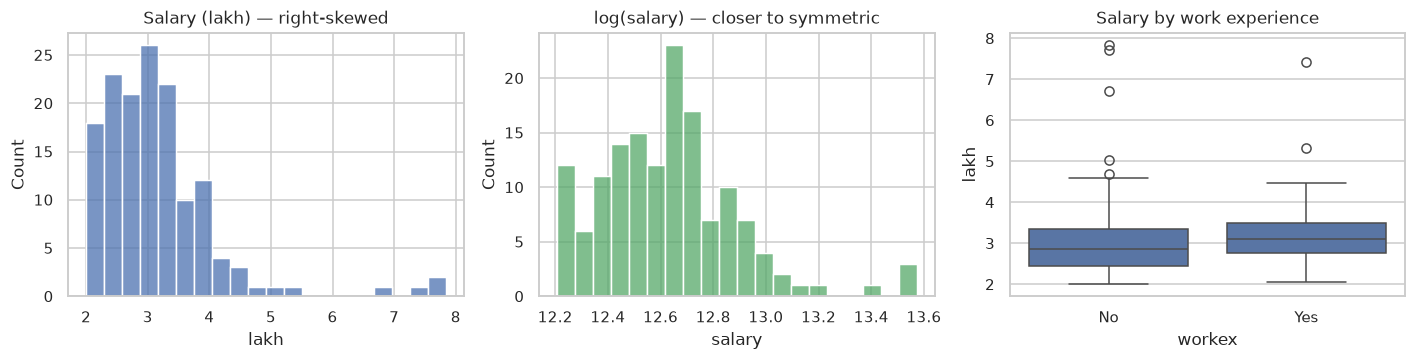

workex
No     286500.0
Yes    311000.0
Name: salary, dtype: float64
gender
F    275000.0
M    312000.0
Name: salary, dtype: float64


In [7]:
placed = pl[pl["status"] == "Placed"].copy()
s = placed["salary"]
print(s.describe().round(0))
print("skew:", round(s.skew(), 2), "| skew of log(salary):", round(np.log(s).skew(), 2))
q1, q3 = s.quantile([.25, .75]); upper = q3 + 1.5 * (q3 - q1)
print(f"IQR upper fence = {upper:,.0f}; packages above it: {(s > upper).sum()}")
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
sns.histplot(s / 1e5, bins=20, ax=ax[0]); ax[0].set(title="Salary (lakh) — right-skewed", xlabel="lakh")
sns.histplot(np.log(s), bins=20, ax=ax[1], color="C2"); ax[1].set(title="log(salary) — closer to symmetric")
sns.boxplot(data=placed, x="workex", y=s / 1e5, ax=ax[2]); ax[2].set(title="Salary by work experience", ylabel="lakh")
plt.tight_layout(); save("pl_salary")
print(placed.groupby("workex")["salary"].median(), placed.groupby("gender")["salary"].median(), sep="\n")

### 1.3 Univariate analysis of the scores

In [8]:
num_summary(pl[pct])

,count,mean,std,min,25%,50%,75%,max,skew,kurt,n_iqr_outliers,n_zeros
ssc_p,215.0,66.92,10.79,40.0,59.58,67.57,73.73,89.40,-0.11,-0.32,0,0
hsc_p,215.0,66.21,11.24,37.0,57.91,67.43,73.88,96.87,-0.23,-0.07,0,0
degree_p,215.0,66.52,7.64,50.0,60.95,67.03,71.72,83.63,-0.07,-0.55,0,0
etest_p,215.0,72.97,12.38,50.0,63.74,73.18,80.80,98.00,0.08,-0.53,0,0
mba_p,215.0,62.28,5.42,51.2,58.31,62.15,66.11,76.00,0.07,-0.59,0,0


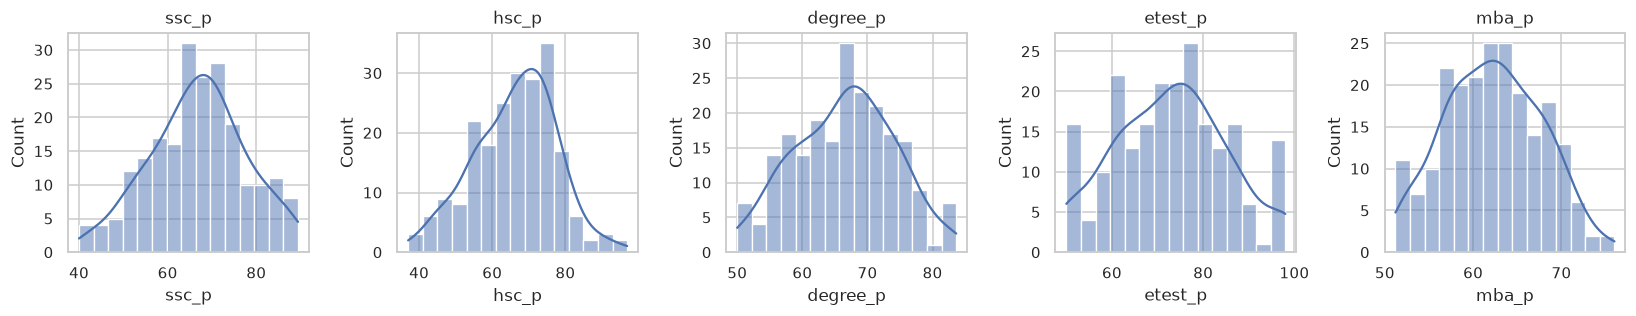

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, c in zip(axes, pct):
    sns.histplot(pl[c], bins=15, kde=True, ax=ax); ax.set_title(c)
plt.tight_layout(); save("pl_hist")

*Reading:* all five are roughly symmetric (|skew| small), within valid ranges; extreme marks are genuine toppers, not errors → **no outlier removal**.

### 1.4 Which scores separate placed from not placed? (numeric vs binary target)

In [10]:
pl["placed"] = (pl["status"] == "Placed").astype(int)
print(pl.groupby("status")[pct].mean().round(1).T, "\n")
point_biserial(pl, pct, "placed")

status    Not Placed  Placed
ssc_p           57.8    71.2
hsc_p           58.5    69.9
degree_p        61.5    68.9
etest_p         71.2    73.8
mba_p           63.1    61.9 



,feature,r_pb,p_value
0,ssc_p,0.583,0.000
1,hsc_p,0.475,0.000
2,degree_p,0.456,0.000
4,mba_p,-0.109,0.113
3,etest_p,0.100,0.146


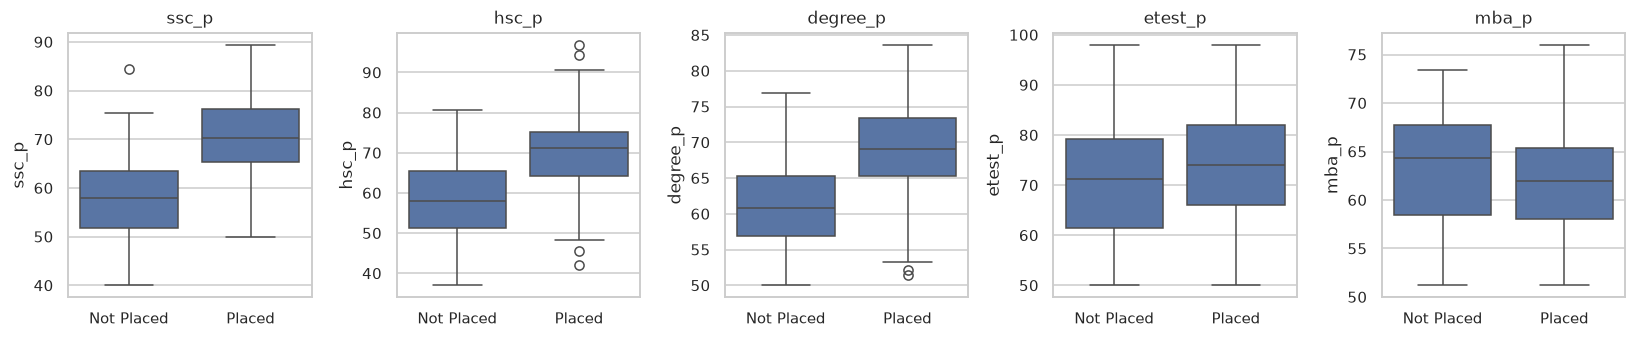

ssc_p     placed mean  71.2 vs  57.8  Welch t = 10.39, p = 8.3e-19
hsc_p     placed mean  69.9 vs  58.5  Welch t =  7.69, p = 3.8e-12
degree_p  placed mean  68.9 vs  61.5  Welch t =  7.54, p = 5.8e-12
etest_p   placed mean  73.8 vs  71.2  Welch t =  1.46, p = 0.15
mba_p     placed mean  61.9 vs  63.1  Welch t = -1.61, p = 0.11


In [11]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3.2))
for ax, c in zip(axes, pct):
    sns.boxplot(data=pl, x="status", y=c, ax=ax, order=["Not Placed", "Placed"]); ax.set(title=c, xlabel="")
plt.tight_layout(); save("pl_box_by_status")
for c in pct:
    a, b = pl.loc[pl.placed == 1, c], pl.loc[pl.placed == 0, c]
    t, p = stats.ttest_ind(a, b, equal_var=False)
    print(f"{c:9s} placed mean {a.mean():5.1f} vs {b.mean():5.1f}  Welch t = {t:5.2f}, p = {p:.2g}")

*Reading:* school (`ssc_p`, `hsc_p`) and degree percentages are much higher for placed students (boxes barely overlap);
`etest_p` and `mba_p` hardly differ. Interview insight: *the recruiter filters look at the academic track record, not the MBA score.*

### 1.5 Placement rate by thresholds — turning EDA into a rule a placement cell can use

            rate   n
ssc_p               
(0, 55]    0.161  31
(55, 60]   0.346  26
(60, 65]   0.625  32
(65, 70]   0.864  44
(70, 75]   0.806  31
(75, 100]  0.961  51


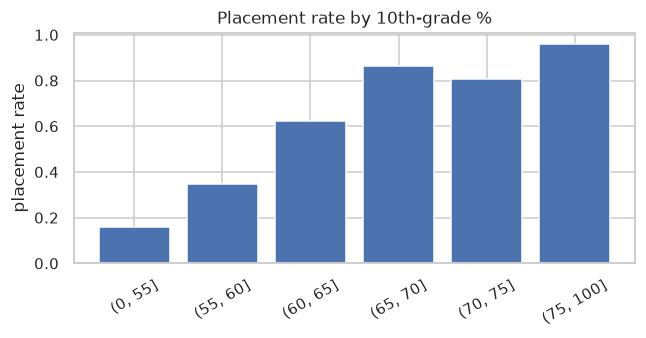

In [12]:
print(rate_by(pl, "ssc_p", "placed", bins=[0, 55, 60, 65, 70, 75, 100]))
fig, ax = plt.subplots(figsize=(6, 3.2))
r = rate_by(pl, "ssc_p", "placed", bins=[0, 55, 60, 65, 70, 75, 100])
ax.bar(r.index.astype(str), r["rate"]); ax.set(title="Placement rate by 10th-grade %", ylabel="placement rate")
plt.xticks(rotation=30); plt.tight_layout(); save("pl_rate_ssc")

### 1.6 Categorical features vs placement (rates, chi-square, Cramér's V)

In [13]:
cats = ["gender", "ssc_b", "hsc_b", "hsc_s", "degree_t", "workex", "specialisation"]
rows = []
for c in cats:
    t = pd.crosstab(pl[c], pl["placed"])
    chi2, p, *_ = stats.chi2_contingency(t)
    rows.append((c, round(cramers_v(pl[c], pl["placed"]), 3), round(p, 4),
                 rate_by(pl, c, "placed")["rate"].to_dict()))
pd.DataFrame(rows, columns=["feature", "cramers_v", "chi2_p", "placement_rate_by_level"]).sort_values("cramers_v", ascending=False)

,feature,cramers_v,chi2_p,placement_rate_by_level
5,workex,0.171,0.019,"{'No': 0.627, 'Yes': 0.8}"
6,specialisation,0.164,0.024,"{'Mkt&Fin': 0.75, 'Mkt&HR': 0.596}"
3,hsc_s,0.060,0.678,"{'Arts': 0.8, 'Commerce': 0.681, 'Science': 0...."
4,degree_t,0.048,0.784,"{'Comm&Mgmt': 0.696, 'Others': 0.647, 'Sci&Tec..."
0,gender,0.027,0.810,"{'F': 0.662, 'M': 0.688}"
1,ssc_b,0.027,0.798,"{'Central': 0.667, 'Others': 0.692}"
2,hsc_b,0.000,1.000,"{'Central': 0.679, 'Others': 0.679}"


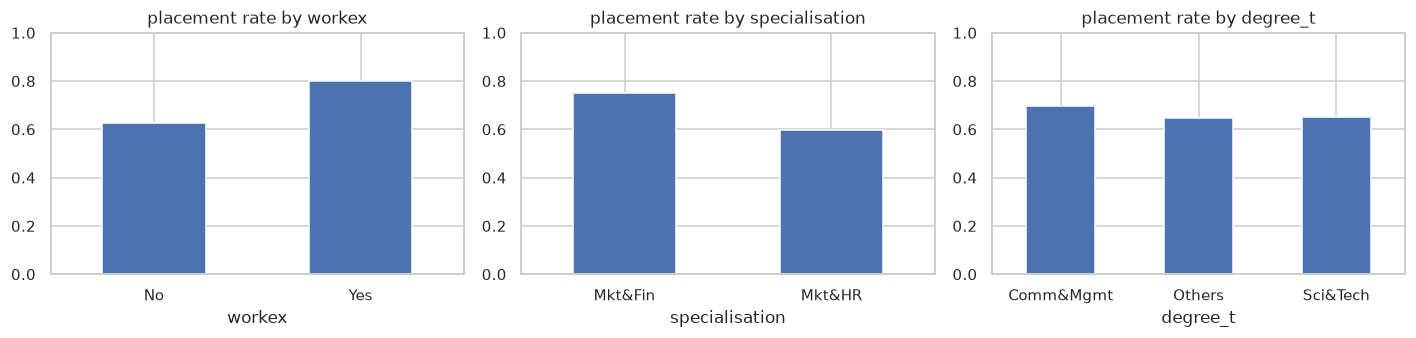

specialisation  Mkt&Fin  Mkt&HR
workex                         
No                 0.70    0.55
Yes                0.85    0.73


In [14]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
for a, c in zip(ax, ["workex", "specialisation", "degree_t"]):
    rate_by(pl, c, "placed")["rate"].plot(kind="bar", ax=a, rot=0, color="C0"); a.set(title=f"placement rate by {c}", ylim=(0, 1))
plt.tight_layout(); save("pl_cat_rates")
print(pd.crosstab(pl["workex"], pl["specialisation"], values=pl["placed"], aggfunc="mean").round(2))

*Reading:* work experience and Mkt&Fin specialisation raise placement; boards make little difference (Cramér's V near 0, large p);
`degree_t = Others` has very few students, so its rate is unreliable — always show `n` beside a rate.

### 1.7 Correlations among numeric features and multicollinearity

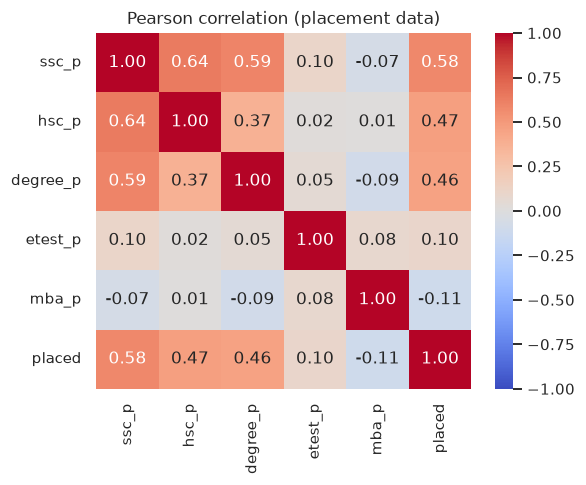

ssc_p       2.28
hsc_p       1.70
degree_p    1.55
etest_p     1.02
mba_p       1.02
Name: VIF, dtype: float64


In [15]:
corr = pl[pct + ["placed"]].corr()
plt.figure(figsize=(5.5, 4.2)); sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Pearson correlation (placement data)"); save("pl_corr")
print(vif(pl[pct]))

*Reading:* academic scores correlate moderately with each other (one ‘academic ability’ factor) but VIFs are small (< 5): no serious multicollinearity.

### 1.8 Multivariate view and a sanity-check model

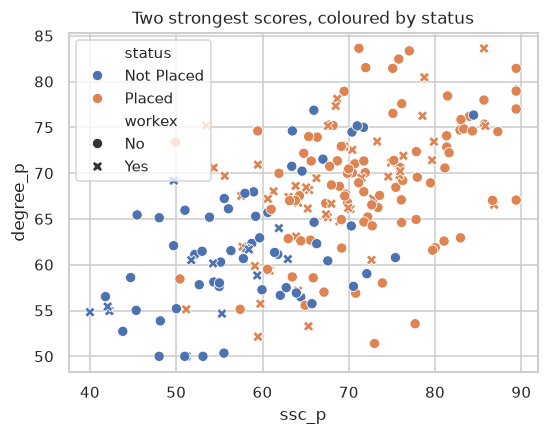

CV ROC AUC using EDA-selected features (no salary): 0.916 +/- 0.024


In [16]:
plt.figure(figsize=(5.5, 4))
sns.scatterplot(data=pl, x="ssc_p", y="degree_p", hue="status", style="workex", s=45)
plt.title("Two strongest scores, coloured by status"); save("pl_scatter")
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
X = pd.get_dummies(pl[pct + ["workex", "specialisation", "gender"]], drop_first=True).astype(float)
cv = StratifiedKFold(5, shuffle=True, random_state=0)
auc = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)), X, pl["placed"], cv=cv, scoring="roc_auc")
print("CV ROC AUC using EDA-selected features (no salary):", auc.mean().round(3), "+/-", auc.std().round(3))

### 1.9 Findings, in the order you would say them
1. 215 students, 15 columns, no duplicates, all percentages valid; **salary is missing exactly for non-placed students → leak, drop for placement modelling.**
2. Placement is about 70% (mildly imbalanced): accuracy is usable but report precision/recall too.
3. 10th, 12th and degree percentages are the strongest drivers (point-biserial r ≈ 0.4–0.6); employability test and MBA % barely matter.
4. Work experience and Mkt&Fin specialisation raise placement; school boards do not matter.
5. Among placed students, salary is right-skewed (log it for modelling) with a few genuine high packages; higher with work experience.
6. A simple logistic regression on these features reaches CV AUC ≈ 0.9 — the EDA already told us most of the story.

---
# Case 2 — HR Analytics: will a data-science candidate look for a job change? (REAL data)
Very close to Naukri data: candidate profile, experience, company, training hours; **target = 1** if the candidate is looking for a new job.

In [17]:
hr = load_csv("Data_gathering/dataset/aug_train.csv")
print(hr.shape); hr.head()

(19158, 14)


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [18]:
overview(hr)

,dtype,missing,missing_%,n_unique,example
enrollee_id,int64,0,0.0,19158,8949
city,str,0,0.0,123,city_103
city_development_index,float64,0,0.0,93,0.92
gender,str,4508,23.5,3,Male
relevent_experience,str,0,0.0,2,Has relevent experience
enrolled_university,str,386,2.0,3,no_enrollment
education_level,str,460,2.4,5,Graduate
major_discipline,str,2813,14.7,6,STEM
experience,str,65,0.3,22,>20
company_size,str,5938,31.0,8,50-99


In [19]:
print("target balance:\n", hr["target"].value_counts(normalize=True).round(3))
for c in ["experience", "last_new_job", "company_size"]:
    print(f"\n{c}:", hr[c].value_counts(dropna=False).to_dict())

target balance:
 target
0.0    0.751
1.0    0.249
Name: proportion, dtype: float64

experience: {'>20': 3286, '5': 1430, '4': 1403, '3': 1354, '6': 1216, '2': 1127, '7': 1028, '10': 985, '9': 980, '8': 802, '15': 686, '11': 664, '14': 586, '1': 549, '<1': 522, '16': 508, '12': 494, '13': 399, '17': 342, '19': 304, '18': 280, '20': 148, nan: 65}

last_new_job: {'1': 8040, '>4': 3290, '2': 2900, 'never': 2452, '4': 1029, '3': 1024, nan: 423}

company_size: {nan: 5938, '50-99': 3083, '100-500': 2571, '10000+': 2019, '10/49': 1471, '1000-4999': 1328, '<10': 1308, '500-999': 877, '5000-9999': 563}


*Reading:* `experience` and `last_new_job` are **numbers stored as text** with special codes (`>20`, `<1`, `never`, `>4`);
`company_size` has a malformed label **`10/49`** (should be `10-49`). 25% positives → imbalanced. Five columns have substantial missing data.

### 2.1 Cleaning types (the bit interviewers watch you do live)

In [20]:
hr["experience_num"] = hr["experience"].replace({">20": "21", "<1": "0"}).astype(float)
hr["last_new_job_num"] = hr["last_new_job"].replace({">4": "5", "never": "0"}).astype(float)
hr["company_size"] = hr["company_size"].replace({"10/49": "10-49"})
size_order = ["<10", "10-49", "50-99", "100-500", "500-999", "1000-4999", "5000-9999", "10000+"]
hr["company_size_ord"] = hr["company_size"].map({s: i for i, s in enumerate(size_order)})
print(hr[["experience_num", "last_new_job_num", "company_size_ord"]].describe().round(2))
print("duplicates ignoring id:", hr.drop(columns="enrollee_id").duplicated().sum())

       experience_num  last_new_job_num  company_size_ord
count        19093.00          18735.00          13220.00
mean            10.10              2.00              3.25
std              6.78              1.68              2.19
min              0.00              0.00              0.00
25%              4.00              1.00              2.00
50%              9.00              1.00              3.00
75%             16.00              3.00              5.00
max             21.00              5.00              7.00
duplicates ignoring id: 49


### 2.2 Missing values: random or informative?

In [21]:
mv = missing_vs_target(hr[["gender", "enrolled_university", "education_level", "major_discipline",
                           "experience", "company_size", "company_type", "last_new_job", "target"]], "target")
mv.sort_values("missing_%", ascending=False)

,column,missing_%,target_rate_if_missing,target_rate_if_present
6,company_type,32.0,0.388,0.184
5,company_size,31.0,0.406,0.179
0,gender,23.5,0.308,0.231
3,major_discipline,14.7,0.195,0.259
2,education_level,2.4,0.226,0.250
7,last_new_job,2.2,0.364,0.247
1,enrolled_university,2.0,0.319,0.248
4,experience,0.3,0.354,0.249


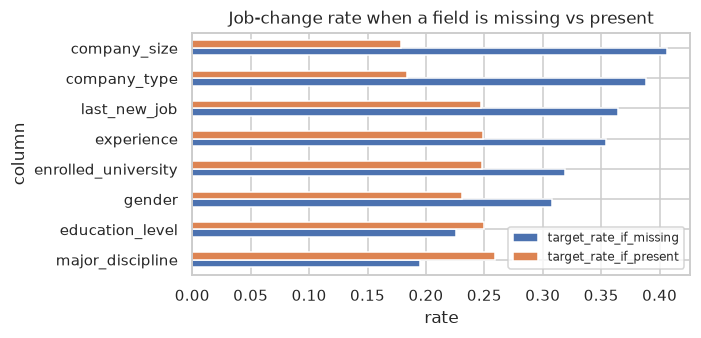

In [22]:
plt.figure(figsize=(6.5, 3.2))
m = mv.set_index("column")[["target_rate_if_missing", "target_rate_if_present"]].sort_values("target_rate_if_missing")
m.plot(kind="barh", ax=plt.gca()); plt.legend(loc="lower right", fontsize=8); plt.title("Job-change rate when a field is missing vs present"); plt.xlabel("rate")
plt.tight_layout(); save("hr_missing_vs_target")

*Reading:* when `company_size` or `company_type` is blank, the job-change rate is about **40%** vs **~18%** when present.
Blank company fields plausibly mean *currently not employed* → a strong, legitimate signal (not MCAR).
**Decision:** do not drop these rows; encode missingness as its own category (`"Unknown"`) or add a missing indicator; tree models can use NaN directly.

### 2.3 Numeric features: shape and relation to the target

In [23]:
num_summary(hr[["city_development_index", "training_hours", "experience_num", "last_new_job_num"]])

,count,mean,std,min,25%,50%,75%,max,skew,kurt,n_iqr_outliers,n_zeros
city_development_index,19158.0,0.83,0.12,0.45,0.74,0.9,0.92,0.95,-1.00,-0.54,17,0
training_hours,19158.0,65.37,60.06,1.00,23.00,47.0,88.00,336.00,1.82,3.84,984,0
experience_num,19093.0,10.10,6.78,0.00,4.00,9.0,16.00,21.00,0.41,-1.17,0,522
last_new_job_num,18735.0,2.00,1.68,0.00,1.00,1.0,3.00,5.00,0.80,-0.76,0,2452


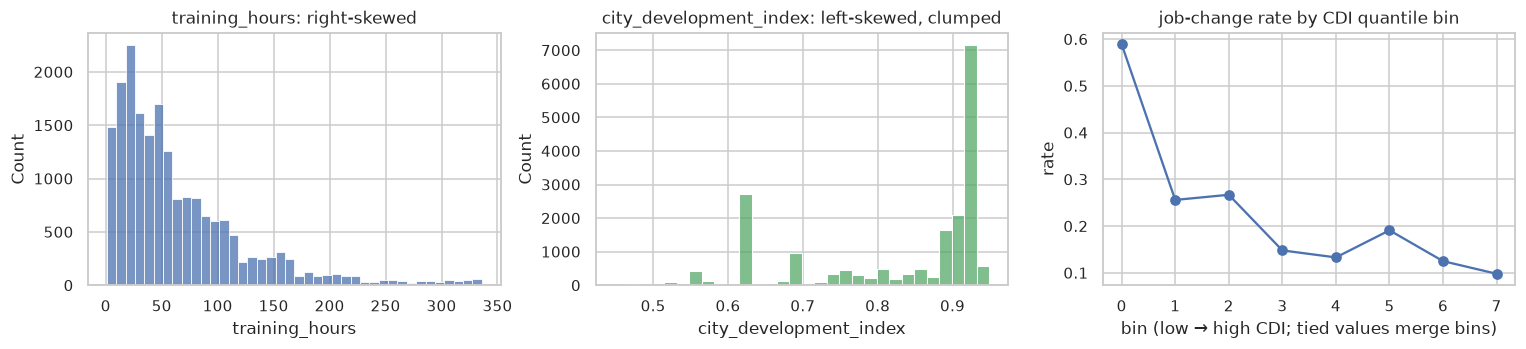

                         rate     n
city_development_index             
(0.447, 0.691]          0.551  3869
(0.691, 0.878]          0.206  3827
(0.878, 0.92]           0.178  8925
(0.92, 0.949]           0.104  2537
                  feature   r_pb  p_value
0  city_development_index -0.342    0.000
2          experience_num -0.177    0.000
3        last_new_job_num -0.083    0.000
1          training_hours -0.022    0.003


In [24]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.3))
sns.histplot(hr["training_hours"], bins=40, ax=ax[0]); ax[0].set_title("training_hours: right-skewed")
sns.histplot(hr["city_development_index"], bins=30, ax=ax[1], color="C2"); ax[1].set_title("city_development_index: left-skewed, clumped")
r = rate_by(hr, "city_development_index", "target", q=10)
ax[2].plot(range(len(r)), r["rate"], marker="o"); ax[2].set(title="job-change rate by CDI quantile bin", xlabel="bin (low → high CDI; tied values merge bins)", ylabel="rate")
plt.tight_layout(); save("hr_numeric")
print(rate_by(hr, "city_development_index", "target", q=5))
print(point_biserial(hr, ["city_development_index", "training_hours", "experience_num", "last_new_job_num"], "target"))

*Reading:* **city development index** is the strongest numeric signal and is **non-linear**: candidates in the least developed cities change jobs
at roughly 55% vs about 10% in the most developed. `training_hours` is skewed and nearly unrelated to the target (r ≈ −0.02).

### 2.4 Categorical features vs target

In [25]:
for c in ["relevent_experience", "enrolled_university", "education_level", "company_type", "last_new_job"]:
    print(rate_by(hr, c, "target").sort_values("rate", ascending=False), "\n")

                          rate      n
relevent_experience                  
No relevent experience   0.338   5366
Has relevent experience  0.215  13792 

                      rate      n
enrolled_university              
Full time course     0.381   3757
MISSING              0.319    386
Part time course     0.252   1198
no_enrollment        0.211  13817 

                  rate      n
education_level              
Graduate         0.280  11598
MISSING          0.226    460
Masters          0.214   4361
High School      0.195   2017
Phd              0.140    414
Primary School   0.133    308 

                      rate     n
company_type                    
MISSING              0.388  6140
Other                0.240   121
Early Stage Startup  0.235   603
Public Sector        0.220   955
NGO                  0.186   521
Pvt Ltd              0.181  9817
Funded Startup       0.140  1001 

               rate     n
last_new_job             
MISSING       0.364   423
never         0.301  

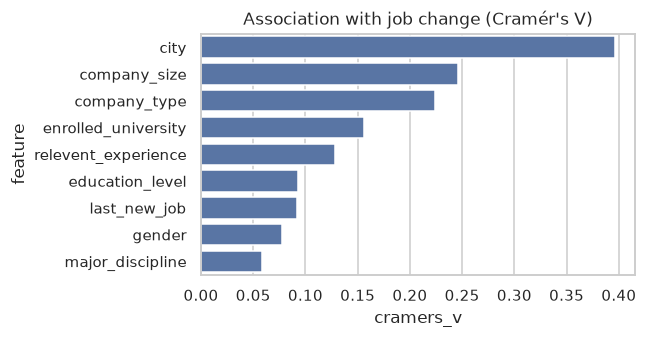

,feature,cramers_v
0,city,0.396
5,company_size,0.246
6,company_type,0.224
2,enrolled_university,0.156
1,relevent_experience,0.128
3,education_level,0.093
7,last_new_job,0.092
8,gender,0.078
4,major_discipline,0.058


In [26]:
rows = [(c, round(cramers_v(hr[c].fillna("MISSING"), hr["target"]), 3)) for c in
        ["city", "relevent_experience", "enrolled_university", "education_level", "major_discipline",
         "company_size", "company_type", "last_new_job", "gender"]]
cv_tab = pd.DataFrame(rows, columns=["feature", "cramers_v"]).sort_values("cramers_v", ascending=False)
plt.figure(figsize=(6, 3.2)); sns.barplot(data=cv_tab, y="feature", x="cramers_v", color="C0")
plt.title("Association with job change (Cramér's V)"); plt.tight_layout(); save("hr_cramers")
cv_tab

### 2.5 High-cardinality `city`: why one-hot is a poor idea and what to do

In [27]:
cs = hr.groupby("city").agg(n=("target", "size"), rate=("target", "mean"), cdi=("city_development_index", "first"))
print("cities:", len(cs), "| cities with < 20 candidates:", (cs["n"] < 20).sum())
print("Is CDI constant within each city?", (hr.groupby("city")["city_development_index"].nunique() == 1).all())
print("corr(city rate, city CDI) =", round(cs["rate"].corr(cs["cdi"]), 3))
prior, m = hr["target"].mean(), 20
cs["smoothed_rate"] = (cs["n"] * cs["rate"] + m * prior) / (cs["n"] + m)
cs.sort_values("n", ascending=False).head(8)

cities: 123 | cities with < 20 candidates: 44
Is CDI constant within each city? True
corr(city rate, city CDI) = -0.705


,n,rate,cdi,smoothed_rate
city,,,,
city_103,4355,0.213,0.920,0.213
city_21,2702,0.591,0.624,0.589
city_16,1533,0.117,0.910,0.118
city_114,1336,0.100,0.926,0.102
city_160,845,0.236,0.920,0.236
city_136,586,0.104,0.897,0.109
city_67,431,0.132,0.855,0.137
city_75,305,0.102,0.939,0.111


*Reading:* 123 cities, many with few rows → raw city rates are noisy; and `city_development_index` is a **city-level attribute** (one value per city),
so it already summarises most of the city effect. Options: keep CDI, add **frequency** encoding of city, and an out-of-fold **smoothed target encoding** (shown).

### 2.6 Experience: non-linear, and interacting with relevant experience

                 mean  size
experience_num             
(-1, 2]         0.384  2198
(2, 5]          0.322  4187
(5, 10]         0.252  5011
(10, 15]        0.191  2829
(15, 21]        0.156  4868


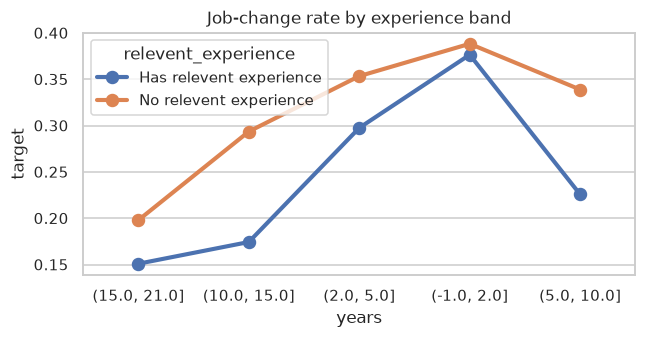

In [28]:
e = hr.groupby(pd.cut(hr["experience_num"], [-1, 2, 5, 10, 15, 21]), observed=True)["target"].agg(["mean", "size"]).round(3)
print(e)
plt.figure(figsize=(6, 3.2))
sns.pointplot(data=hr, x=pd.cut(hr["experience_num"], [-1, 2, 5, 10, 15, 21]).astype(str), y="target",
              hue="relevent_experience", errorbar=None)
plt.title("Job-change rate by experience band"); plt.xlabel("years"); plt.tight_layout(); save("hr_experience")

### 2.7 Findings
1. 19,158 rows; 25% positives (imbalanced → PR AUC / F1, stratified splits, class weights).
2. Type fixes needed: `experience`, `last_new_job` (text with codes), malformed `company_size` label `10/49`.
3. **Missingness is informative**: blank company fields ⇒ ~40% job-change rate vs ~18% → keep as a category.
4. **City development index** is the strongest driver and is non-linear (≈55% in least developed cities vs ≈10% in most developed).
5. Juniors, people without relevant experience and full-time students change jobs more; `training_hours` is nearly irrelevant.
6. `city` has 123 levels → frequency/target encoding, not one-hot.

---
# Case 3 — Titanic (REAL data): interactions, text features, group-wise imputation

In [29]:
ti = load_csv("understanding_your_data_eda/train.csv")
print(ti.shape); overview(ti)

(891, 12)


,dtype,missing,missing_%,n_unique,example
PassengerId,int64,0,0.0,891,1
Survived,int64,0,0.0,2,0
Pclass,int64,0,0.0,3,3
Name,str,0,0.0,891,"Braund, Mr. Owen Harris"
Sex,str,0,0.0,2,male
Age,float64,177,19.9,88,22.0
SibSp,int64,0,0.0,7,1
Parch,int64,0,0.0,7,0
Ticket,str,0,0.0,681,A/5 21171
Fare,float64,0,0.0,248,7.25


survival rate: 0.384
         rate    n
Sex               
female  0.742  314
male    0.189  577
         rate    n
Pclass            
1       0.630  216
2       0.473  184
3       0.242  491
Sex     female   male
Pclass               
1        0.968  0.369
2        0.921  0.157
3        0.500  0.135


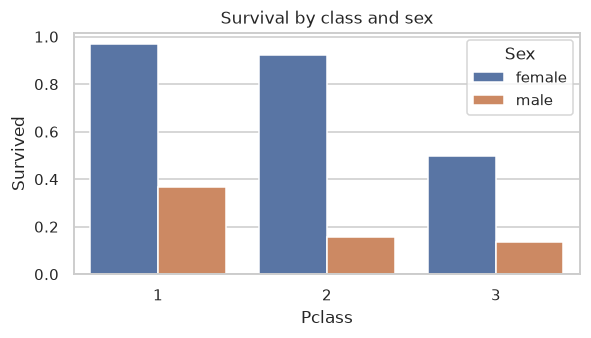

In [30]:
print("survival rate:", ti["Survived"].mean().round(3))
print(rate_by(ti, "Sex", "Survived")); print(rate_by(ti, "Pclass", "Survived"))
print(pd.crosstab(ti["Pclass"], ti["Sex"], values=ti["Survived"], aggfunc="mean").round(3))
plt.figure(figsize=(5.5, 3.2))
sns.barplot(data=ti, x="Pclass", y="Survived", hue="Sex", errorbar=None); plt.title("Survival by class and sex")
plt.tight_layout(); save("ti_class_sex")

*Reading (interaction):* women in 1st/2nd class survived at >90%, women in 3rd class 50%; men low everywhere. The effect of class
**depends on** sex — a tree captures it automatically; a linear model needs an interaction feature.

In [31]:
ti["Title"] = ti["Name"].str.extract(r",\s*([^\.]+)\.")[0]
ti["Title"] = ti["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
ti.loc[~ti["Title"].isin(["Mr", "Mrs", "Miss", "Master"]), "Title"] = "Rare"
print(ti.groupby("Title").agg(n=("Survived", "size"), survival=("Survived", "mean"), median_age=("Age", "median")).round(2))
ti["Age_filled"] = ti["Age"].fillna(ti.groupby("Title")["Age"].transform("median"))
print("global median age:", ti["Age"].median(), "| ages imputed:", ti["Age"].isna().sum())

          n  survival  median_age
Title                            
Master   40      0.57         3.5
Miss    185      0.70        21.0
Mr      517      0.16        30.0
Mrs     126      0.79        35.0
Rare     23      0.35        48.5
global median age: 28.0 | ages imputed: 177


*Why title-wise imputation:* `Master` (boys) has median age 3.5 while `Mr` has 30; filling every missing age with the global median (28)
would turn missing boys into adults.

Fare skew: 4.79 | log1p skew: 0.39 | zero fares: 15
             rate    n
FamilySize            
(0, 1]      0.304  537
(1, 4]      0.579  292
(4, 11]     0.161   62
survival if Cabin missing vs present: {False: 0.667, True: 0.3}


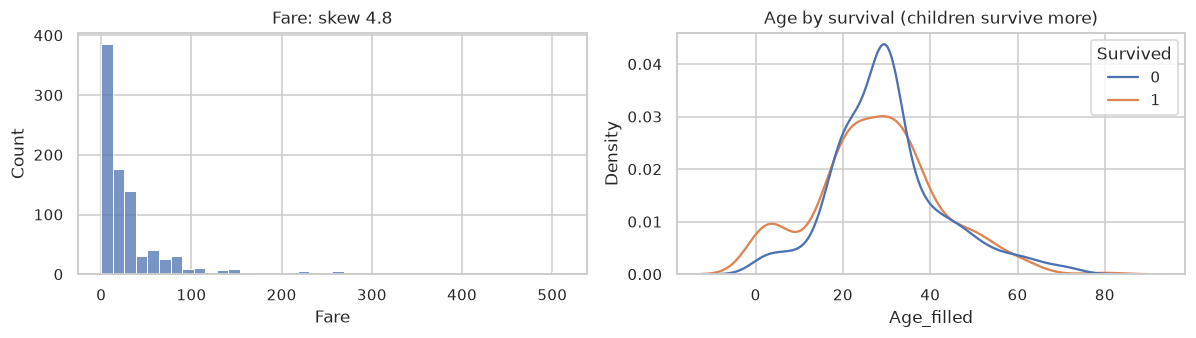

In [32]:
print("Fare skew:", ti["Fare"].skew().round(2), "| log1p skew:", np.log1p(ti["Fare"]).skew().round(2),
      "| zero fares:", (ti["Fare"] == 0).sum())
ti["FamilySize"] = ti["SibSp"] + ti["Parch"] + 1
print(rate_by(ti, "FamilySize", "Survived", bins=[0, 1, 4, 11]))
print("survival if Cabin missing vs present:", ti.groupby(ti["Cabin"].isna())["Survived"].mean().round(3).to_dict())
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
sns.histplot(ti["Fare"], bins=40, ax=ax[0]); ax[0].set_title("Fare: skew 4.8")
sns.kdeplot(data=ti, x="Age_filled", hue="Survived", common_norm=False, ax=ax[1]); ax[1].set_title("Age by survival (children survive more)")
plt.tight_layout(); save("ti_fare_age")

### Titanic findings
Sex is the dominant factor, class second, with a strong **interaction**; children (`Master`, age < 12) survived more; medium families (2–4)
survived more than people alone or in big families; missing `Cabin` marks lower classes (informative); `Fare` is very skewed (log it) with 15 zero fares to check.

---
# Case 4 — Pima diabetes (REAL data): disguised missing values

In [33]:
pi = load_csv("Module_1_Foundation_of_ML_AI/dataset/diabetes.csv")
print(pi.shape, "| isna().sum() total:", pi.isna().sum().sum())
num_summary(pi)

(768, 9) | isna().sum() total: 0


,count,mean,std,min,25%,50%,75%,max,skew,kurt,n_iqr_outliers,n_zeros
Pregnancies,768.0,3.85,3.37,0.00,1.00,3.00,6.00,17.00,0.90,0.16,4,111
Glucose,768.0,120.89,31.97,0.00,99.00,117.00,140.25,199.00,0.17,0.64,5,5
BloodPressure,768.0,69.11,19.36,0.00,62.00,72.00,80.00,122.00,-1.84,5.18,45,35
SkinThickness,768.0,20.54,15.95,0.00,0.00,23.00,32.00,99.00,0.11,-0.52,1,227
Insulin,768.0,79.80,115.24,0.00,0.00,30.50,127.25,846.00,2.27,7.21,34,374
BMI,768.0,31.99,7.88,0.00,27.30,32.00,36.60,67.10,-0.43,3.29,19,11
DiabetesPedigreeFunction,768.0,0.47,0.33,0.08,0.24,0.37,0.63,2.42,1.92,5.59,29,0
Age,768.0,33.24,11.76,21.00,24.00,29.00,41.00,81.00,1.13,0.64,9,0
Outcome,768.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00,0.64,-1.60,0,500


`isna()` says **no missing values** — but `n_zeros` shows 374 zero Insulin, 227 zero SkinThickness, 35 zero BloodPressure, 11 zero BMI,
5 zero Glucose. A living person cannot have blood pressure 0 or BMI 0: these are **missing values coded as 0**. (Zero Pregnancies is valid.)

Pregnancies                  0.0
Glucose                      0.7
BloodPressure                4.6
SkinThickness               29.6
Insulin                     48.7
BMI                          1.4
DiabetesPedigreeFunction     0.0
Age                          0.0
Outcome                      0.0
dtype: float64

Glucose mean with zeros: 120.89 | after fixing: 121.69

medians by outcome after fixing:
 Outcome                       0      1
Pregnancies                 2.0    4.0
Glucose                   107.0  140.0
BloodPressure              70.0   74.5
SkinThickness              27.0   32.0
Insulin                   102.5  169.5
BMI                        30.1   34.3
DiabetesPedigreeFunction    0.3    0.4
Age                        27.0   36.0
                    feature   r_pb  p_value
1                   Glucose  0.495      0.0
5                       BMI  0.314      0.0
4                   Insulin  0.303      0.0
3             SkinThickness  0.260      0.0
7                       Ag

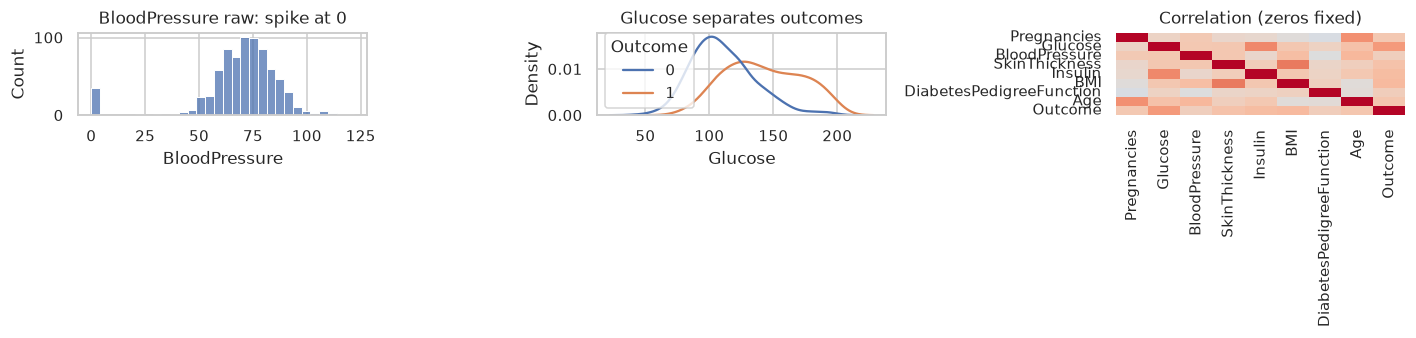

In [34]:
impossible_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
pi2 = pi.copy(); pi2[impossible_zero] = pi2[impossible_zero].replace(0, np.nan)
print((pi2.isna().mean() * 100).round(1))
print("\nGlucose mean with zeros:", pi["Glucose"].mean().round(2), "| after fixing:", pi2["Glucose"].mean().round(2))
print("\nmedians by outcome after fixing:\n", pi2.groupby("Outcome").median().round(1).T)
print(point_biserial(pi2, pi2.columns.drop("Outcome"), "Outcome"))
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
sns.histplot(pi["BloodPressure"], bins=30, ax=ax[0]); ax[0].set_title("BloodPressure raw: spike at 0")
sns.kdeplot(data=pi2, x="Glucose", hue="Outcome", common_norm=False, ax=ax[1]); ax[1].set_title("Glucose separates outcomes")
sns.heatmap(pi2.corr(), cmap="coolwarm", vmin=-1, vmax=1, ax=ax[2], cbar=False); ax[2].set_title("Correlation (zeros fixed)")
plt.tight_layout(); save("pi_overview")

### Pima findings
Disguised missing values (Insulin 49% missing!) must be recoded before any statistic; imputation should use medians computed **without the
outcome** and inside a pipeline. Glucose is by far the strongest predictor (r ≈ 0.50), then BMI and Insulin (≈ 0.30). Insulin shows a
striking trap: with the zeros left in, the *median* insulin of diabetic patients is 0 (most of them simply were not measured);
after recoding zeros as missing it is 169.5 vs 102.5 for non-diabetic patients.

---
# Exercises (do them before the interview)
1. On the HR data, build `missing_count` per row and check the job-change rate by it.
2. On Titanic, compute survival by `Embarked` with counts and explain why `C` looks better (hint: class mix).
3. On Pima, impute with `KNNImputer` vs median and compare the Glucose–Outcome point-biserial correlation.
4. On the placement data, compute Spearman instead of Pearson correlations; do conclusions change?
5. For each dataset, write a 6-line findings summary in “because I see X, I will do Y” form.